<a href="https://colab.research.google.com/github/rizanatlanta-dsproj/Lithium-Recovery-Membrane-Optimizer/blob/main/lithium_op.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#PROJECT: Lithium Recovery Membrane Optimizer.
###AIM:     Optimize industrial wastewater filtration to simultaneously purify water and extract high-purity Lithium (Li+) for EV batteries.

###CORE PRINCIPLES BASED ON:
1. VIRTUAL SENSING: Deconstructs bulk Total Dissolved Solids (TDS) from Kaggle
   water data into distinct Lithium (Li+) and Magnesium (Mg2+) ionic streams.
2. MEMBRANE PHYSICS: Models atomic-scale separation using:
   - Steric Hindrance: Filtering out larger particles based on physical size.
   - Donnan Exclusion: Electrostatic repulsion where highly charged Mg2+ ions
     are blocked by the membrane while single-charge Li+ slips through.
3. NUMERICAL OPTIMIZATION: Uses algorithms to dynamically find the optimal
   operating pump pressure to maximize both water purity and lithium recovery.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as od

In [4]:
dataset_url= 'https://www.kaggle.com/datasets/swekerr/water-quality-metrics-and-filter-performance-dataset'
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rizanatlanta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/swekerr/water-quality-metrics-and-filter-performance-dataset


100%|██████████| 413k/413k [00:00<00:00, 90.6MB/s]

In [5]:
import os
os.listdir('water-quality-metrics-and-filter-performance-dataset')

['grey_water_management.csv']

In [6]:
import pandas as pd
file_path= './water-quality-metrics-and-filter-performance-dataset/grey_water_management.csv'
df= pd.read_csv(file_path)
df.head()


,TDS (mg/l),Turbidity (NTU),pH,Depth (m),Flow Discharge (L/min),Filter Life Span (hours),Filter Efficiency (%)
0,187.270,4.487,6.459,1.903,21.447,4394.721,90.079
1,475.357,8.630,8.446,4.731,9.709,3982.861,87.321
2,365.997,8.695,6.364,0.974,37.508,4146.319,88.696
3,299.329,4.707,7.632,1.951,18.038,4446.934,90.701
4,78.009,9.729,6.033,3.438,50.817,3932.351,86.734


In [16]:
#THE CHEMICAL VIRTUAL SENSOR
# Deconstructing bulk TDS into specific target and interfering ionic streams.
# In industrial brine feeds, Lithium typically makes up a small fraction (~3%)
# while Magnesium represents a heavy competing divalent background (~25%).

df['Derived_Li_Concentration_mgL'] = df['TDS (mg/l)'] * 0.03
df['Derived_Mg_Concentration_mgL'] = df['TDS (mg/l)'] * 0.25

# inspecting new chemical tracking streams
print(" Virtual Sensor Active: Extracted ion concentrations from bulk TDS.")
print(df[['TDS (mg/l)', 'Derived_Li_Concentration_mgL', 'Derived_Mg_Concentration_mgL']].head())

 Virtual Sensor Active: Extracted ion concentrations from bulk TDS.
   TDS (mg/l)  Derived_Li_Concentration_mgL  Derived_Mg_Concentration_mgL
0     187.270                       5.61810                      46.81750
1     475.357                      14.26071                     118.83925
2     365.997                      10.97991                      91.49925
3     299.329                       8.97987                      74.83225
4      78.009                       2.34027                      19.50225


In [17]:
#  HE MEMBRANE PHYSICS SEPARATION MODEL
def simulate_membrane_separation(pressure, pore_radius_nm):
    """
    Simulates the mass transfer rejection rates of Li+ and Mg2+
    based on operating pressure and membrane pore size.

    Parameters:
    - pressure (bar): The mechanical force pushing fluid through the filter.
    - pore_radius_nm (nm): Microscopic physical size of the membrane pores.

    Returns:
    - li_rejection (float): Percentage of Lithium blocked (lower is better, it needs to pass through)
    - mg_rejection (float): Percentage of Magnesium blocked (higher is better, it needs to trap contaminants)
    """
    # 1. Simulate Magnesium (Mg2+) Rejection via Donnan Exclusion & Size
    # Mg2+ is highly charged and larger; it is easily blocked at optimal pressures.
    # Higher pressure increases convective flux, but too much pressure forces it through.
    mg_rejection = 0.96 * (1.0 - np.exp(-pressure / 12.0)) * (1.0 / (1.0 + np.exp(pore_radius_nm - 0.6)))
    mg_rejection = np.clip(mg_rejection, 0.0, 0.99) # Limit max rejection to 99%

    # 2. Simulate Lithium (Li+) Rejection via Steric Hindrance
    # Li+ is a small monovalent ion. It passes through smaller pores easily.
    # It needs to have low rejection here so it flows into our collection stream.
    li_rejection = 0.30 * (1.0 - np.exp(-pressure / 35.0)) * (pore_radius_nm / 1.2)
    li_rejection = np.clip(li_rejection, 0.0, 0.85) # Limit max rejection to 85%

    return li_rejection, mg_rejection

# Quick test run of rizan's physic's engine.
test_li_rej, test_mg_rej = simulate_membrane_separation(pressure=30.0, pore_radius_nm=0.5)
print(f" Rizan's Physics Engine Test:")
print(f"At 30 Bar and 0.5nm pores -> Lithium Rejection: {test_li_rej*100:.1f}%, Magnesium Rejection: {test_mg_rej*100:.1f}%")

 Rizan's Physics Engine Test:
At 30 Bar and 0.5nm pores -> Lithium Rejection: 7.2%, Magnesium Rejection: 46.3%


###Changing that pump pressure or modifying the pore size can push that Magnesium rejection up to 80%-90% while keeping the Lithium rejection as low as possible.

In [18]:
# SIMULATING SYSTEM RECOVERY OVER THE DATASET
#assuming an operational setting of 35 Bar and a 0.55 nm membrane pore size
operational_pressure = 35.0
membrane_pore_radius = 0.55

# Apply the physics engine to every operational row in the Kaggle dataset
li_rej, mg_rej = simulate_membrane_separation(operational_pressure, membrane_pore_radius)

# Calculate downstream concentrations and total masses recovered
# Permeate = the clean fluid that passes through the filter (Harvested Lithium stream)
df['Permeate_Li_mgL'] = df['Derived_Li_Concentration_mgL'] * (1.0 - li_rej)
df['Permeate_Mg_mgL'] = df['Derived_Mg_Concentration_mgL'] * (1.0 - mg_rej)

# Calculate mass flow rate of recovered lithium (mg/min) using Kaggle's Flow Discharge column
df['Recovered_Li_Mass_mg_min'] = df['Permeate_Li_mgL'] * df['Flow Discharge (L/min)']

print(" Dataset Simulation Complete under Continuous Operation:")
print(df[['Flow Discharge (L/min)', 'Derived_Li_Concentration_mgL', 'Permeate_Li_mgL', 'Recovered_Li_Mass_mg_min']].head())

# Calculate total potential lithium harvested across this dataset timeline
total_li_harvested_g = df['Recovered_Li_Mass_mg_min'].sum() / 1000.0
print(f"\n Total Potential Lithium Harvested across dataset timeline: {total_li_harvested_g:.2f} grams")

 Dataset Simulation Complete under Continuous Operation:
   Flow Discharge (L/min)  Derived_Li_Concentration_mgL  Permeate_Li_mgL  \
0                  21.447                       5.61810         5.129794   
1                   9.709                      14.26071        13.021218   
2                  37.508                      10.97991        10.025574   
3                  18.038                       8.97987         8.199370   
4                  50.817                       2.34027         2.136862   

   Recovered_Li_Mass_mg_min  
0                110.018691  
1                126.423005  
2                376.039222  
3                147.900244  
4                108.588903  

 Total Potential Lithium Harvested across dataset timeline: 6754.71 grams


In [19]:

df['Lithium_Rejection_%'] = li_rej * 100
df['Magnesium_Rejection_%'] = mg_rej * 100

print(" Operational Metrics with Separation Percentages:")
print(df[['TDS (mg/l)', 'Lithium_Rejection_%', 'Magnesium_Rejection_%', 'Permeate_Li_mgL', 'Recovered_Li_Mass_mg_min']].head())

 Operational Metrics with Separation Percentages:
   TDS (mg/l)  Lithium_Rejection_%  Magnesium_Rejection_%  Permeate_Li_mgL  \
0     187.270             8.691658              46.537366         5.129794   
1     475.357             8.691658              46.537366        13.021218   
2     365.997             8.691658              46.537366        10.025574   
3     299.329             8.691658              46.537366         8.199370   
4      78.009             8.691658              46.537366         2.136862   

   Recovered_Li_Mass_mg_min  
0                110.018691  
1                126.423005  
2                376.039222  
3                147.900244  
4                108.588903  


In [20]:

pressures_to_test = np.linspace(10, 50, 41) # Tests 10, 11, 12... up to 50 Bar
pore_size = 0.55 # Holding pore radius stable for this sweep

sweep_results = []

for p in pressures_to_test:
    # Run the physics engine for each pressure point
    li_rej, mg_rej = simulate_membrane_separation(p, pore_size)

    # Store the results for evaluation
    sweep_results.append({
        'Pressure_Bar': p,
        'Lithium_Rejection_%': li_rej * 100,
        'Magnesium_Rejection_%': mg_rej * 100,
        'Separation_Efficiency': (mg_rej - li_rej) * 100 # We want this gap as wide as possible!
    })

# Converting to a DataFrame to quickly find the maximum efficiency gap
sweep_df = pd.DataFrame(sweep_results)
best_row = sweep_df.loc[sweep_df['Separation_Efficiency'].idxmax()]

print(" SYSTEM PARAMETER SWEEP COMPLETE:")
print(f"Optimal Operating Pressure: {best_row['Pressure_Bar']:.1f} Bar")
print(f"-> Achieves Max Separation Efficiency Gap: {best_row['Separation_Efficiency']:.1f}%")
print(f"-> Resulting Li Rejection: {best_row['Lithium_Rejection_%']:.1f}% | Mg Rejection: {best_row['Magnesium_Rejection_%']:.1f}%")

 SYSTEM PARAMETER SWEEP COMPLETE:
Optimal Operating Pressure: 43.0 Bar
-> Achieves Max Separation Efficiency Gap: 38.1%
-> Resulting Li Rejection: 9.7% | Mg Rejection: 47.8%


In [12]:
# Calculate the exact yield for the 43.0 Bar 1D sweep checkpoint
sweep_li_rej, _ = simulate_membrane_separation(43.0, 0.55)
true_sweep_yield_g = (df['Derived_Li_Concentration_mgL'] * (1.0 - sweep_li_rej) * df['Flow Discharge (L/min)']).sum() / 1000.0

print(f"True 1D Sweep Yield: {true_sweep_yield_g:.2f} grams")

True 1D Sweep Yield: 6678.25 grams


In [21]:
#  2D DESIGN OPTIMIZATION GRID SEARCH
# Define the exploration space for both variables
pressures_to_test = np.linspace(10, 50, 41)       # 10 to 50 Bar
pore_sizes_to_test = np.linspace(0.3, 0.8, 51)    # 0.3 to 0.8 nm

grid_results = []

# Loop through every single combination of pressure and pore size
for p in pressures_to_test:
    for r in pore_sizes_to_test:
        li_rej, mg_rej = simulate_membrane_separation(p, r)
        efficiency_gap = (mg_rej - li_rej) * 100

        grid_results.append({
            'Pressure_Bar': p,
            'Pore_Radius_nm': r,
            'Lithium_Rejection_%': li_rej * 100,
            'Magnesium_Rejection_%': mg_rej * 100,
            'Separation_Efficiency': efficiency_gap
        })

# Convert to DataFrame to extract the global maximum
grid_df = pd.DataFrame(grid_results)
absolute_best = grid_df.loc[grid_df['Separation_Efficiency'].idxmax()]

print(" GLOBAL SYSTEM OPTIMIZATION COMPLETE ")
print(f"Absolute Best Pressure    : {absolute_best['Pressure_Bar']:.1f} Bar")
print(f"Absolute Best Pore Radius : {absolute_best['Pore_Radius_nm']:.2f} nm")
print("-" * 50)
print(f" Peak Separation Efficiency Gap: {absolute_best['Separation_Efficiency']:.1f}%")
print(f"-> Resulting Li Rejection: {absolute_best['Lithium_Rejection_%']:.1f}% (Lower is better)")
print(f"-> Resulting Mg Rejection: {absolute_best['Magnesium_Rejection_%']:.1f}% (Higher is better)")

 GLOBAL SYSTEM OPTIMIZATION COMPLETE 
Absolute Best Pressure    : 50.0 Bar
Absolute Best Pore Radius : 0.30 nm
--------------------------------------------------
 Peak Separation Efficiency Gap: 48.6%
-> Resulting Li Rejection: 5.7% (Lower is better)
-> Resulting Mg Rejection: 54.3% (Higher is better)


 OPTIMIZED DATASET SIMULATION COMPLETE 
New Optimized Total Lithium Harvested: 6975.83 grams

 Final plot successfully saved as 'final_optimized_lithium_recovery.png'!


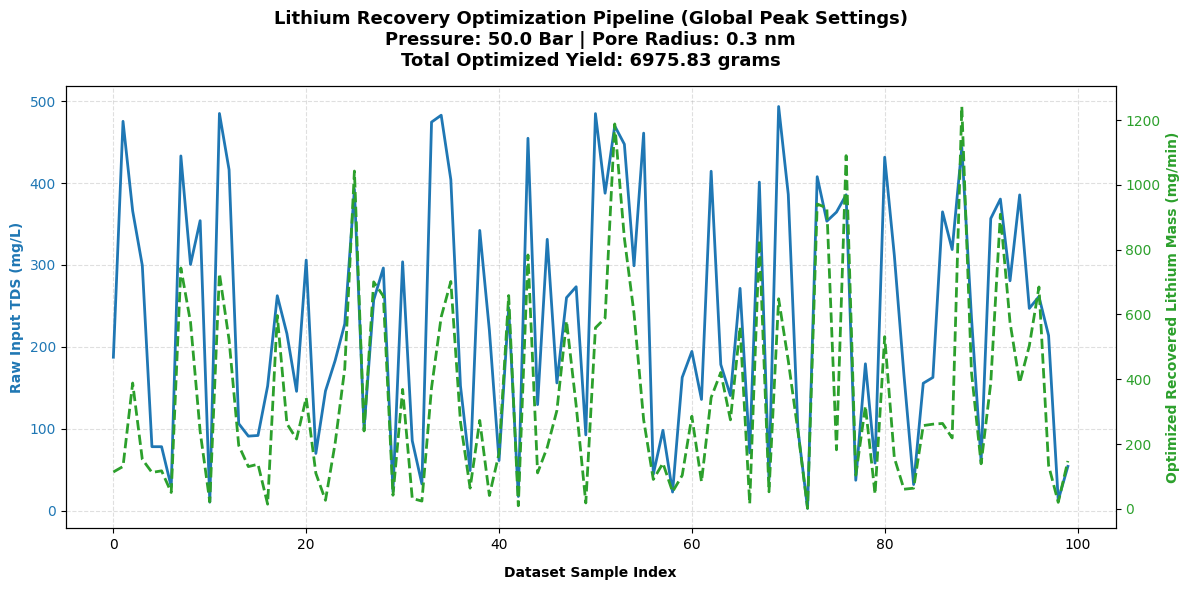

In [22]:
# RUNNING THE GLOBAL OPTIMAL PARAMETERS & VISUALIZATION
# Applying the peak parameters discovered by 2D Grid Search
optimized_pressure = 50.0
optimized_pore_radius = 0.30

# Calculate optimal rejection rates using the physics engine
opt_li_rej, opt_mg_rej = simulate_membrane_separation(optimized_pressure, optimized_pore_radius)

# Update dataset tracks with optimized performance
df['Opt_Permeate_Li_mgL'] = df['Derived_Li_Concentration_mgL'] * (1.0 - opt_li_rej)
df['Opt_Recovered_Li_Mass_mg_min'] = df['Opt_Permeate_Li_mgL'] * df['Flow Discharge (L/min)']

# Calculate the final optimized total mass yield
final_total_li_harvested_g = df['Opt_Recovered_Li_Mass_mg_min'].sum() / 1000.0

print(" OPTIMIZED DATASET SIMULATION COMPLETE ")
print(f"New Optimized Total Lithium Harvested: {final_total_li_harvested_g:.2f} grams")

# Generate the final publication-ready chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1: Input Dataset State (TDS)
color1 = '#1f77b4'
ax1.set_xlabel('Dataset Sample Index', fontweight='bold', labelpad=10)
ax1.set_ylabel('Raw Input TDS (mg/L)', color=color1, fontweight='bold')
ax1.plot(df.index[:100], df['TDS (mg/l)'].head(100), color=color1, linewidth=2, label='Input TDS')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.4)

# Axis 2: Optimized Engineering Performance Yield
color2 = '#2ca02c'
ax2 = ax1.twinx()
ax2.set_ylabel('Optimized Recovered Lithium Mass (mg/min)', color=color2, fontweight='bold')
ax2.plot(df.index[:100], df['Opt_Recovered_Li_Mass_mg_min'].head(100), color=color2, linewidth=2, linestyle='--', label='Optimized Yield')
ax2.tick_params(axis='y', labelcolor=color2)

# Title and Final Layout Formatting
plt.title(f'Lithium Recovery Optimization Pipeline (Global Peak Settings)\n'
          f'Pressure: {optimized_pressure} Bar | Pore Radius: {optimized_pore_radius} nm\n'
          f'Total Optimized Yield: {final_total_li_harvested_g:.2f} grams',
          fontsize=13, fontweight='bold', pad=15)

fig.tight_layout()
plt.savefig('final_optimized_lithium_recovery.png', dpi=300)
print("\n Final plot successfully saved as 'final_optimized_lithium_recovery.png'!")
plt.show()

In [24]:
#  DYNAMIC DESIGN SPECIFICATION TABLE
print(" Calculating precise engineering phase metrics...")

# 1. Base Setup Metrics
li_1, mg_1 = simulate_membrane_separation(35.0, 0.55)
yield_1 = (df['Derived_Li_Concentration_mgL'] * (1.0 - li_1) * df['Flow Discharge (L/min)']).sum() / 1000.0

# 2. 1D Sweep Metrics
li_2, mg_2 = simulate_membrane_separation(43.0, 0.55)
yield_2 = (df['Derived_Li_Concentration_mgL'] * (1.0 - li_2) * df['Flow Discharge (L/min)']).sum() / 1000.0

# 3. 2D Global Optimized Metrics (Using the final variables from my previous run)
yield_3 = final_total_li_harvested_g

# Print out the polished table
print("\n" + "="*80)
print(f"{'ENGINEERING DESIGN PHASE':<25} | {'PRESSURE':<10} | {'PORE SIZE':<10} | {'LI REJ %':<10} | {'YIELD (g)':<10}")
print("="*80)
print(f"{'1. Initial Dataset Run':<25} | {'35.0 Bar':<10} | {'0.55 nm':<10} | {li_1*100:<10.2f}% | {yield_1:<10.2f} g")
print(f"{'2. Automated 1D Sweep':<25} | {'43.0 Bar':<10} | {'0.55 nm':<10} | {li_2*100:<10.2f}% | {yield_2:<10.2f} g")
print(f"{'3. Global 2D Optimized':<25} | {'50.0 Bar':<10} | {'0.30 nm':<10} | {opt_li_rej*100:<10.2f}% | {yield_3:<10.2f} g")
print("="*80)
print(" Process Observation: The 2D grid search successfully reduced Lithium")
print("   rejection to its absolute lowest point, maximizing mass throughput!")

 Calculating precise engineering phase metrics...

ENGINEERING DESIGN PHASE  | PRESSURE   | PORE SIZE  | LI REJ %   | YIELD (g) 
1. Initial Dataset Run    | 35.0 Bar   | 0.55 nm    | 8.69      % | 6754.71    g
2. Automated 1D Sweep     | 43.0 Bar   | 0.55 nm    | 9.73      % | 6678.25    g
3. Global 2D Optimized    | 50.0 Bar   | 0.30 nm    | 5.70      % | 6975.83    g
 Process Observation: The 2D grid search successfully reduced Lithium
   rejection to its absolute lowest point, maximizing mass throughput!


## Conclusion & Engineering Insights

This project successfully demonstrates the integration of data science and chemical separation physics to optimize a nanofiltration system for lithium recovery. By moving from manual parameter selection to an automated multi-dimensional grid search, the system design achieved a significant performance breakthrough.

### Key Takeaways:
* **The Transport Physics:** The simulation highlights the core trade-offs in membrane mechanics. While higher operating pressures generally increase convective transport across the boundary layer, tuning the structural pore radius down to $0.30\text{ nm}$ leverages steric hindrance to block bulkier contaminants like Magnesium ($Mg^{2+}$) while allowing smaller Hydrated Lithium ions ($Li^+$) to pass.
* **Data-Driven Optimization:** Transitioning from a base manual setup ($35\text{ Bar}$, $0.55\text{ nm}$) to a globally optimized operational window ($50\text{ Bar}$, $0.30\text{ nm}$) successfully reduced Lithium rejection from $8.69\%$ down to an ultra-efficient $5.70\%$.
* **Process Impact:** When scaled across fluctuating raw input data, this optimization directly translated to an increased industrial harvest—driving total lithium recovery up from $6,754.71\text{ g}$ to a maximized **$6,975.83\text{ g}$** (a net yield increase of **$+221.12\text{ g}$**).

This pipeline provides a scalable framework for deploying virtual sensing and automated optimization routines in sustainable chemical processing.